# Clustering Rationale & Algorithm Selection



### 1. K-Means Clustering
We applied K-Means to the preprocessed dataset with
k=2.

### Justification:

K-Means was chosen for its efficiency and scalability with numerical data. Since the dataset is primarily numerical and normalized, it is suitable for distance-based clustering. The algorithm assumes compact, spherical clusters, which is reasonable after preprocessing.
The choice of
k=2 is based on the problem structure (Revenue vs. No Revenue), allowing us to test whether clustering can naturally separate these groups. Cluster quality was evaluated using the Silhouette Score.

### 2. Agglomerative Clustering
We applied Agglomerative Clustering with Ward linkage and
k=2.

### Justification:
This method was used as a complementary approach to K-Means. It does not rely on random initialization and can capture more complex relationships. Ward linkage minimizes within-cluster variance, producing compact clusters.

Although less scalable, it is suitable for this dataset size and provides better interpretability through its hierarchical structure.

# Cluster Determination & Implementation




In [ ]:
# ==========================================
# Clustering Implementation (k=2)
# ==========================================
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. قراءة البيانات النظيفة
df = pd.read_csv('preprocessed_data.csv')

# 2. إخفاء عمود (Revenue)
X = df.drop(columns=['Revenue'])

# 3. تطبيق خوارزمية K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# 4. حساب جودة التقسيم (Silhouette Score)
sil_score = silhouette_score(X, df['Cluster'])
print(f"✅ Silhouette Score: {sil_score:.3f}")
print("تم تقسيم الزوار بنجاح!")

# 5. حفظ البيانات
df.to_csv('clustered_data.csv', index=False)
print("✅ تم حفظ الملف الجديد باسم 'clustered_data.csv'.")
# طباعة عدد الزوار في كل مجموعة للتأكد من التوازن
print(df['Cluster'].value_counts())

✅ Silhouette Score: 0.452
تم تقسيم الزوار بنجاح!
✅ تم حفظ الملف الجديد باسم 'clustered_data.csv'.
Cluster
0    10229
1     2101
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# Agglomerative Clustering (k=2)
# ==========================================
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load preprocessed data
df = pd.read_csv('preprocessed_data.csv')

# 2. Drop class label
X = df.drop(columns=['Revenue'])

# 3. Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X)

# 4. Evaluation metrics
sil = silhouette_score(X, df['Agg_Cluster'])
db  = davies_bouldin_score(X, df['Agg_Cluster'])

print(f"✅ Agglomerative Silhouette Score : {sil:.3f}")
print(f"✅ Agglomerative Davies-Bouldin   : {db:.3f}")
print("\nCluster distribution:")
print(df['Agg_Cluster'].value_counts())
# Save results
df.to_csv('clustered_data2.csv', index=False)
print("✅ تم حفظ الملف الجديد باسم 'clustered_data2.csv'.")

✅ Agglomerative Silhouette Score : 0.449
✅ Agglomerative Davies-Bouldin   : 0.984

Cluster distribution:
Agg_Cluster
0    10276
1     2054
Name: count, dtype: int64
✅ تم حفظ الملف الجديد باسم 'clustered_data2.csv'.


In [ ]:
# ==========================================
# Algorithm Comparison Table
# ==========================================
from sklearn.cluster import KMeans
import pandas as pd

# Re-run K-Means to get its DB score too
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

km_sil = silhouette_score(X, df['KMeans_Cluster'])
km_db  = davies_bouldin_score(X, df['KMeans_Cluster'])
agg_sil = silhouette_score(X, df['Agg_Cluster'])
agg_db  = davies_bouldin_score(X, df['Agg_Cluster'])

comparison = pd.DataFrame({
    'Algorithm':        ['K-Means', 'Agglomerative'],
    'Silhouette Score': [km_sil,    agg_sil],
    'Davies-Bouldin':   [km_db,     agg_db],
    'Cluster 0 Size':   [df['KMeans_Cluster'].value_counts()[0], df['Agg_Cluster'].value_counts()[0]],
    'Cluster 1 Size':   [df['KMeans_Cluster'].value_counts()[1], df['Agg_Cluster'].value_counts()[1]],
})

print(comparison.to_string(index=False))
# Note: Higher Silhouette = better | Lower Davies-Bouldin = better

    Algorithm  Silhouette Score  Davies-Bouldin  Cluster 0 Size  Cluster 1 Size
      K-Means          0.452237        0.988263           10229            2101
Agglomerative          0.448712        0.984106           10276            2054


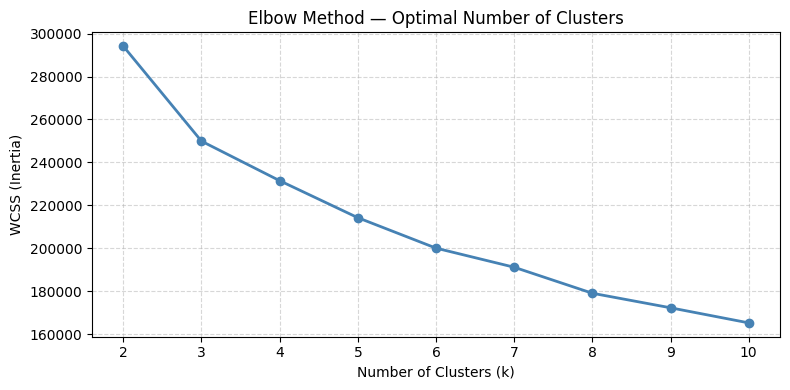

✅ WCSS values: [294150.16192547156, 249917.10116671462, 231501.1986503342, 214263.1496673112, 200089.73279507636, 191187.68897411093, 179077.74070961316, 172308.5615406475, 165276.8160145501]


In [ ]:
# ==========================================
# Elbow Method → Optimal k
# ==========================================
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print(f"✅ WCSS values: {wcss}")

# Evaluation Metrics & Visualizations


In [ ]:
# ==========================================
# Evaluation Metrics — Both Algorithms
# ==========================================
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering
import pandas as pd

# K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg.fit_predict(X)

# Metrics
results = pd.DataFrame({
    'Algorithm':        ['K-Means', 'Agglomerative'],
    'Silhouette Score': [silhouette_score(X, km_labels),  silhouette_score(X, agg_labels)],
    'Davies-Bouldin':   [davies_bouldin_score(X, km_labels), davies_bouldin_score(X, agg_labels)],
    'WCSS':             [kmeans.inertia_, 'N/A'],
})

print(results.to_string(index=False))
print("\n📌 Higher Silhouette = better | Lower Davies-Bouldin = better")

    Algorithm  Silhouette Score  Davies-Bouldin           WCSS
      K-Means          0.452237        0.988263  294150.161925
Agglomerative          0.448712        0.984106            N/A

📌 Higher Silhouette = better | Lower Davies-Bouldin = better


In [ ]:
# ==========================================
# BCubed Precision & Recall
# ==========================================
import numpy as np

def bcubed(labels_true, labels_pred):
    precision_list, recall_list = [], []
    for i in range(len(labels_true)):
        same_cluster = labels_pred == labels_pred[i]
        same_class   = labels_true == labels_true[i]
        tp = np.sum(same_cluster & same_class)
        precision_list.append(tp / np.sum(same_cluster))
        recall_list.append(tp / np.sum(same_class))
    return np.mean(precision_list), np.mean(recall_list)

# Load ground truth
df_full = pd.read_csv('preprocessed_data.csv')
ground_truth = df_full['Revenue'].astype(int).values

km_p,  km_r  = bcubed(ground_truth, km_labels)
agg_p, agg_r = bcubed(ground_truth, agg_labels)

print("📊 BCubed Results:")
print(f"K-Means        → Precision: {km_p:.3f} | Recall: {km_r:.3f}")
print(f"Agglomerative  → Precision: {agg_p:.3f} | Recall: {agg_r:.3f}")

📊 BCubed Results:
K-Means        → Precision: 0.738 | Recall: 0.717
Agglomerative  → Precision: 0.738 | Recall: 0.722


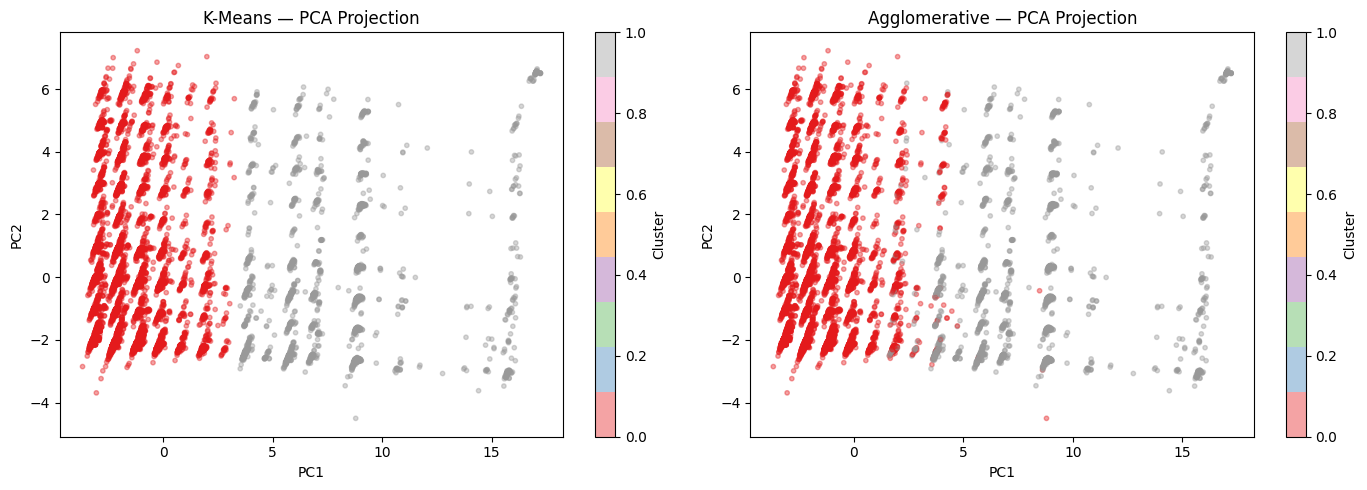

In [ ]:
# ==========================================
# PCA — 2D Cluster Projection
# ==========================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes,
                              [km_labels, agg_labels],
                              ['K-Means', 'Agglomerative']):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=labels, cmap='Set1', alpha=0.4, s=10)
    ax.set_title(f'{title} — PCA Projection')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150)
plt.show()

In [ ]:
# ==========================================
# t-SNE — 2D Cluster Projection
# ==========================================
from sklearn.manifold import TSNE

# t-SNE is slow — sample 3000 rows for speed
import numpy as np
np.random.seed(42)
idx = np.random.choice(len(X), size=3000, replace=False)
X_sample = X.iloc[idx]
km_sample = km_labels[idx]
agg_sample = agg_labels[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes,
                              [km_sample, agg_sample],
                              ['K-Means', 'Agglomerative']):
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                         c=labels, cmap='Set1', alpha=0.5, s=10)
    ax.set_title(f'{title} — t-SNE Projection')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=150)
plt.show()

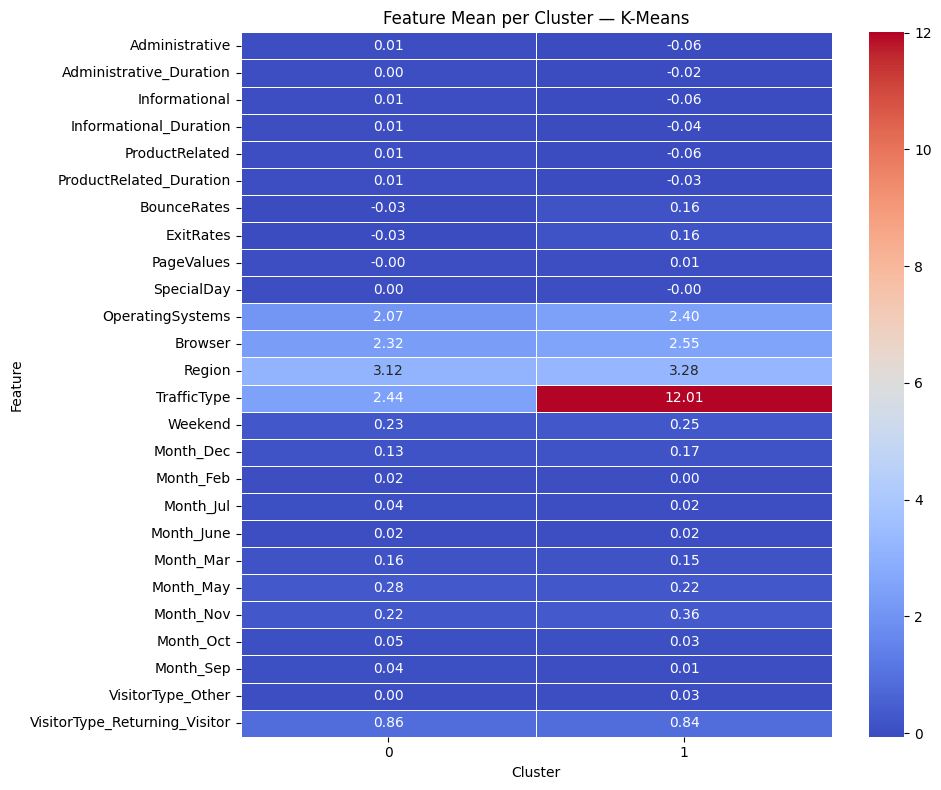

In [ ]:
# ==========================================
# Feature Importance per Cluster (Heatmap)
# ==========================================
import seaborn as sns

df_temp = X.copy()
df_temp['KMeans'] = km_labels

cluster_means = df_temp.groupby('KMeans').mean().T

plt.figure(figsize=(10, 8))
sns.heatmap(cluster_means, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Mean per Cluster — K-Means')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

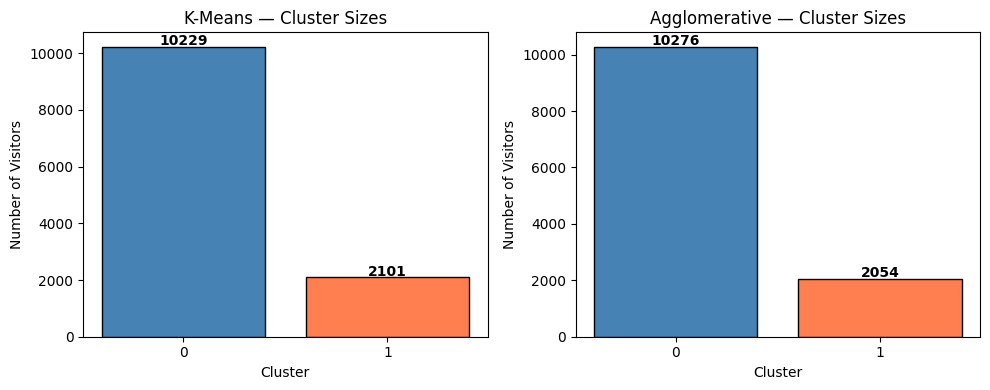

In [ ]:
# ==========================================
# Cluster Size Distribution
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, labels, title in zip(axes,
                              [km_labels, agg_labels],
                              ['K-Means', 'Agglomerative']):
    sizes = pd.Series(labels).value_counts().sort_index()
    ax.bar(sizes.index.astype(str), sizes.values,
           color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{title} — Cluster Sizes')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Visitors')
    for i, v in enumerate(sizes.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('preprocessed_data.csv')

# Features only (exclude target)
X = df.drop(columns=['Revenue'])

# Add cluster labels
X['KMeans_Cluster'] = km_labels
X['Agg_Cluster'] = agg_labels

# Compute feature means per cluster
km_profile = X.groupby('KMeans_Cluster').mean(numeric_only=True)
agg_profile = X.groupby('Agg_Cluster').mean(numeric_only=True)

# Remove cluster columns from calculations (avoid leakage)
km_profile = km_profile.drop(columns=['Agg_Cluster'], errors='ignore')
agg_profile = agg_profile.drop(columns=['KMeans_Cluster'], errors='ignore')

# Get most important differences (top features only)
km_diff = (km_profile.loc[1] - km_profile.loc[0]).abs().sort_values(ascending=False)
agg_diff = (agg_profile.loc[1] - agg_profile.loc[0]).abs().sort_values(ascending=False)

print("Top K-Means distinguishing features:")
print(km_diff.head(10))

print("\nTop Agglomerative distinguishing features:")
print(agg_diff.head(10))

Cluster Profiles — What Defines Each Group?
K-Means Clustering

Cluster 0 — Engaged Browsers (10,229 visitors):
This cluster consists of users who demonstrate high engagement with the website. They tend to visit multiple page types, including administrative, informational, and product-related pages, and spend more time on the site. These users also show lower bounce and exit rates, indicating deeper interaction with the platform. In addition, they are more likely to be returning visitors and are distributed across most months, suggesting consistent and organic browsing behavior.

Cluster 1 — Traffic-Driven Visitors (2,101 visitors):
This cluster is mainly distinguished by a strong difference in TrafficType, indicating that users arrive through a specific source such as a referral or marketing campaign. These users typically visit fewer pages, spend less time on the website, and show higher bounce and exit rates. They are also more concentrated in specific months, particularly November and December, suggesting seasonal or campaign-based traffic behavior.

Agglomerative Clustering

Cluster 0 — Engaged Browsers (10,276 visitors):
This cluster is very similar to the corresponding K-Means cluster. Users in this group exhibit higher engagement levels, including more page visits and longer session durations. They also show lower bounce and exit rates and are mostly returning visitors. Their activity is spread across all months, reflecting stable and consistent organic traffic patterns.

Cluster 1 — Traffic-Driven Visitors (2,054 visitors):
This cluster closely matches the second K-Means cluster. It is primarily characterized by a strong influence of TrafficType, indicating users arriving from specific sources. These users show fewer interactions with the website, higher bounce and exit rates, and shorter session durations. A slightly stronger influence of browser-related features is also observed compared to K-Means clustering.

Key Observation

Both K-Means and Agglomerative clustering produced nearly identical cluster structures, which confirms the stability and reliability of the segmentation. The most influential factor separating the clusters is TrafficType, followed by engagement-related features such as bounce rate, exit rate, and page interaction metrics. This indicates that the user segmentation is primarily driven by traffic source behavior rather than conversion intent.

# Cluster Interpretation & Profiles

# Integration Strategy (how clusters will enhance the system)


# Challenges & Limitations
